In [ ]:
pip install -q torchvision

In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


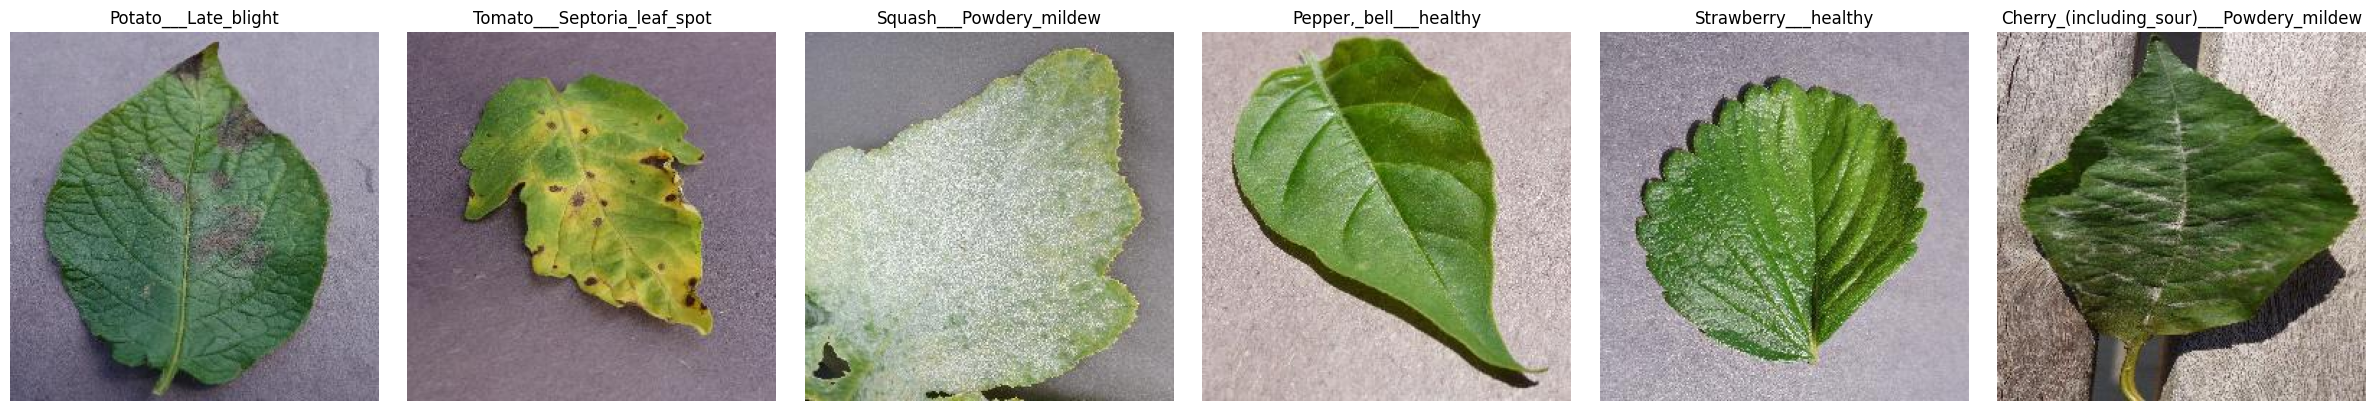

In [ ]:
import math
import matplotlib.pyplot as plt

classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]

# Collect a few images for display
images = []
num_images_to_display = min(6, len(classes)) # Display up to 6 images

for i in range(num_images_to_display):
  class_name = random.choice(classes)
  class_path = os.path.join(train_path, class_name)
  img_name = random.choice(os.listdir(class_path))
  img_path = os.path.join(class_path, img_name)
  img = Image.open(img_path)
  images.append((class_name, img))

num_classes = len(images)
cols = 6 # Adjust columns for better display with a few images
rows = math.ceil(num_classes/cols)

plt.figure(figsize=(4*cols, 4*rows)) # Increase figure size

for i, (class_name, img) in enumerate(images):
  plt.subplot(rows, cols, i + 1)
  plt.title(class_name)
  plt.imshow(img)
  plt.axis("off")

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

# This part was likely for displaying a single image, which is no longer the main goal of this cell.
# print(class_name)
# print(img.width)
# print(img.height)
# display(img)

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(0)
X = torch.randn(200,1)
y = 2*X + 0.5*torch.randn_like(X)
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
  def forward(self, x):
    return (self.weight * x) + self.bias


In [ ]:
torch.manual_seed(42)
model_first = SampleModel()

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.0001)

In [ ]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c ="b")
  plt.scatter(X_test, y_test, c = "g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")

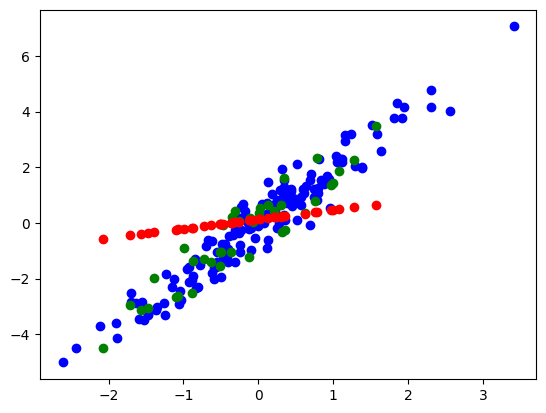

In [ ]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:
torch.manual_seed(42)

epochs = 200 # Increased epochs

for epoch in range(epochs):
  model_first.train()

  y_pred = model_first(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_first.eval()
  with torch.inference_mode():
    test_pred = model_first(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 1.3283710479736328 | test loss 1.1536369323730469
epoch 10 | loss 1.3278535604476929 | test loss 1.1532001495361328
epoch 20 | loss 1.327336311340332 | test loss 1.1527636051177979
epoch 30 | loss 1.326818823814392 | test loss 1.1523268222808838
epoch 40 | loss 1.3263013362884521 | test loss 1.1518899202346802
epoch 50 | loss 1.3257838487625122 | test loss 1.1514532566070557
epoch 60 | loss 1.3252662420272827 | test loss 1.1510164737701416
epoch 70 | loss 1.3247488737106323 | test loss 1.1505796909332275
epoch 80 | loss 1.324231505393982 | test loss 1.1501429080963135
epoch 90 | loss 1.323714017868042 | test loss 1.1497061252593994
epoch 100 | loss 1.3231966495513916 | test loss 1.1492693424224854
epoch 110 | loss 1.3226791620254517 | test loss 1.1488326787948608
epoch 120 | loss 1.3221616744995117 | test loss 1.1483958959579468
epoch 130 | loss 1.3216443061828613 | test loss 1.1479592323303223
epoch 140 | loss 1.3211268186569214 | test loss 1.1475223302841187
epoch 150 

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = datasets.ImageFolder(root="/kaggle", transform=transform)
valid_dataset = datasets.ImageFolder(root="/kaggle", transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
print("Train dataset size:" ,len(train_dataset))
print("Valid dataset size:" ,len(valid_dataset))
print("Train loader size:" ,len(train_loader))
print("Valid loader size:" ,len(valid_loader))



Train dataset size: 175767
Valid dataset size: 175767
Train loader size: 5493
Valid loader size: 5493


In [ ]:

import torch.nn as nn
import torch.optim as optim

class SimpleReg(nn.Module):
    def __init__(self, in_features=1, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self,x):
        return self.net(x)

torch.manual_seed(0)
X = torch.randn(200,1)
y = 2*X + 0.5*torch.randn_like(X)

model = SimpleReg()
loss_fn = nn.MSELoss()
opt = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(200):
    pred = model(X)
    loss = loss_fn(pred, y)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch%50==0:
        print(epoch, loss.item())

print("Sample prediction:", model(torch.tensor([[3.0]])))


0 4.325523853302002
50 0.2889915406703949
100 0.2760104835033417
150 0.2697378396987915
Sample prediction: tensor([[5.9039]], grad_fn=<AddmmBackward0>)


In [ ]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
    return running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28, 256),  # works for 224x224 input
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = SimpleCNN(num_classes=38).to(device)

# Loss & Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18 as ResNet18
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 5
batch_size = 32
learning_rate = 0.001
num_classes = 10

# Data preprocessing and loading
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root="/kaggle", transform=transform)
valid_dataset = datasets.ImageFolder(root="/kaggle", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Define the model
model = ResNet18(weights=None)  # pretrained=False (deprecated)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Create save directory
os.makedirs("saved_models", exist_ok=True)
best_val_acc = 0.0

# Training loop
for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    # Validation loop
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'val_accuracy': best_val_acc
        }, "saved_models/best_resnet18_model.pth")
        print(f"Best model saved with validation accuracy: {val_acc:.2f}%")

# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'val_accuracy': val_acc
}, "saved_models/final_resnet18_model.pth")

print("Final model saved to: saved_models/final_resnet18_model.pth")
print("Best model saved to: saved_models/best_resnet18_model.pth")


# Load the best model
def load_model(model_path, num_classes):
    model = ResNet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    return model, checkpoint

loaded_model, checkpoint = load_model("saved_models/best_resnet18_model.pth", num_classes)
print(f"Loaded model with validation accuracy: {checkpoint.get('val_accuracy', 'N/A')}")

# Set to evaluation mode
loaded_model.eval()

KeyboardInterrupt: 

30/09
## Text Classification Problem Statement

We need to build a text classification model that allows users to describe plant symptoms (e.g., "leaf is slightly rusted") and, based on this text, predict the likely plant disease. This is the second part of our problem statement, complementing the image classification task.

## Data and Labels

To train this model, we need to collect text data. Similar to image classification, this text data will require labels. The labels will be the disease names themselves (e.g., "early blight," "virus," "potato leaf blight").

## Model Approach: Transfer Learning with Hugging Face

We will not be building a transformer model from scratch or writing our own training loops. Instead, we will utilize **transfer learning**. This involves taking a pre-trained model and adjusting its weights to fit our specific dataset. We will be using Hugging Face for this purpose.

### Using Hugging Face

Hugging Face serves as a large repository for machine learning models and datasets, akin to GitHub for ML. It offers various models, including those for Natural Language Processing (NLP) and text classification.

To find a suitable model:

1. Go to Hugging Face.
2. Navigate to the "Models" section.
3. Filter by "NLP" and then "Text Classification."
4. You can sort models by criteria like "most likes" to find popular and potentially effective options.

### Prediction Process

For prediction on a single image:

- Take an image from your dataset (e.g., test data).
- Read it using a library like PIL (Pillow).
- Apply a text transformer (which does not include augmentation).
- Adjust the dimensionality of the image by unsqueezing it at the 0th or 1st dimension. This is crucial because our model was trained on batches of images (e.g., 32 images per batch), but we're predicting for a single image. The input dimensions must match the dimensions the model was trained on.

## Action Items

1. **Find a suitable dataset** for the text classification model, potentially on Hugging Face.
2. **Save your trained image classification model's weights** (or the entire model, though weights are lighter).
3. **Load the saved model weights**.
4. **Perform a prediction** on a single image from your test dataset to verify the model's functionality and ensure it's good enough to proceed.
5. **Understand how to prepare a single image for prediction** by reading it, applying transformations, and adjusting its dimensions to match the model's expected input.

In [ ]:
prediction = []

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = outputs.max(1)
    prediction.extend(predicted.cpu().numpy())

    print(prediction[:1])

[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.int64(0)]
[np.in

KeyboardInterrupt: 

In [ ]:
# torch.save(model.state_dict(), "saved_models/text_classification_model.pth")
# print("Model weights saved")